## Company bankrupt predictive models 

### Importing the libraries 

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import f1_score,recall_score,precision_score 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection  import train_test_split 
from sklearn.model_selection import cross_val_score

# 

### Importing the Dataset 

In [2]:
df = pd.read_csv(r"C:\Users\hp\Downloads\data.csv")

In [3]:
df

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6814,0,0.493687,0.539468,0.543230,0.604455,0.604462,0.998992,0.797409,0.809331,0.303510,...,0.799927,0.000466,0.623620,0.604455,0.840359,0.279606,0.027064,0.566193,1,0.029890
6815,0,0.475162,0.538269,0.524172,0.598308,0.598308,0.998992,0.797414,0.809327,0.303520,...,0.799748,0.001959,0.623931,0.598306,0.840306,0.278132,0.027009,0.566018,1,0.038284
6816,0,0.472725,0.533744,0.520638,0.610444,0.610213,0.998984,0.797401,0.809317,0.303512,...,0.797778,0.002840,0.624156,0.610441,0.840138,0.275789,0.026791,0.565158,1,0.097649
6817,0,0.506264,0.559911,0.554045,0.607850,0.607850,0.999074,0.797500,0.809399,0.303498,...,0.811808,0.002837,0.623957,0.607846,0.841084,0.277547,0.026822,0.565302,1,0.044009


## 

### checking the dataset information 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

## 

### checking the null values in the dataset 

In [5]:
df.isnull().sum()

Bankrupt?                                                   0
 ROA(C) before interest and depreciation before interest    0
 ROA(A) before interest and % after tax                     0
 ROA(B) before interest and depreciation after tax          0
 Operating Gross Margin                                     0
                                                           ..
 Liability to Equity                                        0
 Degree of Financial Leverage (DFL)                         0
 Interest Coverage Ratio (Interest expense to EBIT)         0
 Net Income Flag                                            0
 Equity to Liability                                        0
Length: 96, dtype: int64

## 

### checking the Outliers in the dataset 

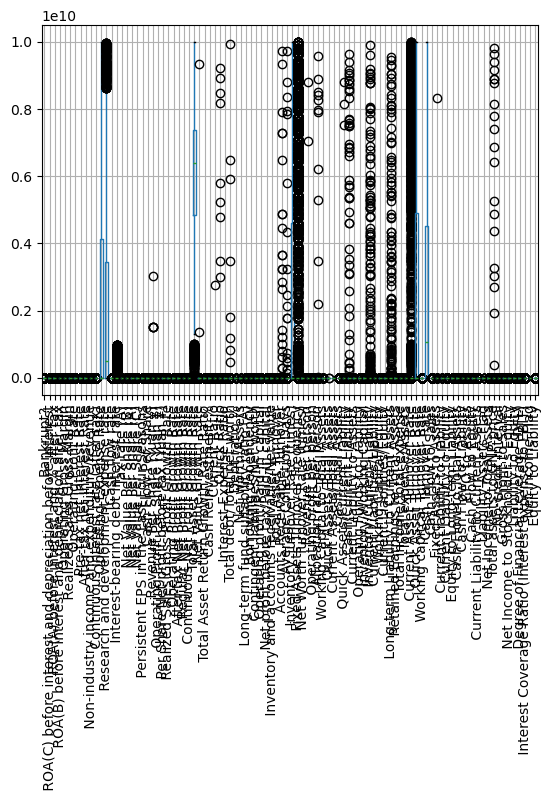

In [6]:
df.boxplot()
plt.xticks(rotation =90 )
plt.show()

## 

### features Extraction from the main databased

### The following all are extracted features

#### the feature are selected based on the requirement to predict the company are bankrupting so this is the important factores
- Financial Health Indicators : Features like ROA, current ratio, and cash flow measure profitability and liquidity, which directly show if a company is financially stable.
- Risk & Debt Management – Debt ratio and interest rate features capture how much risk the company takes through borrowing.
- Performance Trends – Growth rate and profit margin features show whether the company’s performance is improving or declining over time.
- Predictive Power – These features are proven in finance research to strongly influence bankruptcy likelihood, making them reliable predictors.

In [7]:
columns = ['Bankrupt?',
    ' ROA(C) before interest and depreciation before interest',
    ' ROA(A) before interest and % after tax',
    ' ROA(B) before interest and depreciation after tax',
    ' Operating Gross Margin',
    ' Operating Profit Rate',
    ' Net Income to Total Assets',
    ' Gross Profit to Sales',
    " Net Income to Stockholder's Equity",
    ' Debt ratio %',
    ' Total debt/Total net worth',
    ' Liability to Equity',
    ' Equity to Liability',
    ' Degree of Financial Leverage (DFL)',
    ' Interest Coverage Ratio (Interest expense to EBIT)',
    ' Current Ratio',
    ' Quick Ratio',
    ' Cash/Total Assets',
    ' Cash/Current Liability',
    ' Total Asset Turnover',
    ' Inventory Turnover Rate (times)',
    ' Accounts Receivable Turnover',
    ' Working Capital to Total Assets',
    ' Cash Flow to Total Assets',
    ' CFO to Assets',
    ' Cash Flow to Equity',
    ' Cash Flow to Liability',
    ' Operating Profit Growth Rate'
]


In [8]:
features = df[columns]

# 

### Rechecking the Outliers on the new features 

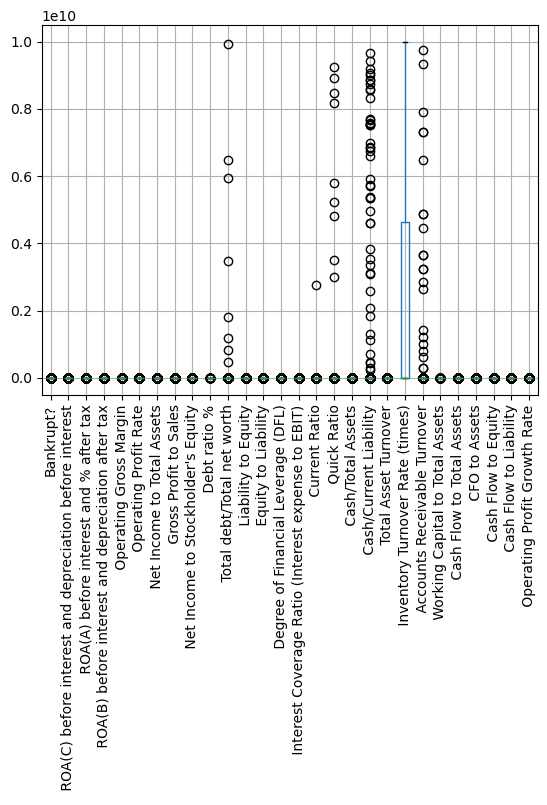

In [9]:
features.boxplot()
plt.xticks(rotation = 90)
plt.show()

# 

### Balancing the outliers by using the Interquartile range 

In [10]:
def balancing_outliers(dataset_name: pd.DataFrame) -> pd.DataFrame:
    numeric_columns = dataset_name.select_dtypes(include=["int", "float"]).columns
    for col in numeric_columns:
        Q1 = dataset_name[col].quantile(0.25)
        Q3 = dataset_name[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_wisker = Q1 - 1.5 * IQR
        upper_wisker = Q3 + 1.5 * IQR
        median_value = dataset_name[col].median()
        dataset_name.loc[dataset_name[col] < lower_wisker, col] = median_value
        dataset_name.loc[dataset_name[col] > upper_wisker, col] = median_value
    
    return dataset_name


# 

### The feature 'Bankrupt' does not have any outliers and this feature is important to classify which companies are bankrupt or not 

In [11]:
new_features = balancing_outliers(features.drop('Bankrupt?',axis = 1))

In [59]:
new_features["Bankrupt?"] = features["Bankrupt?"]

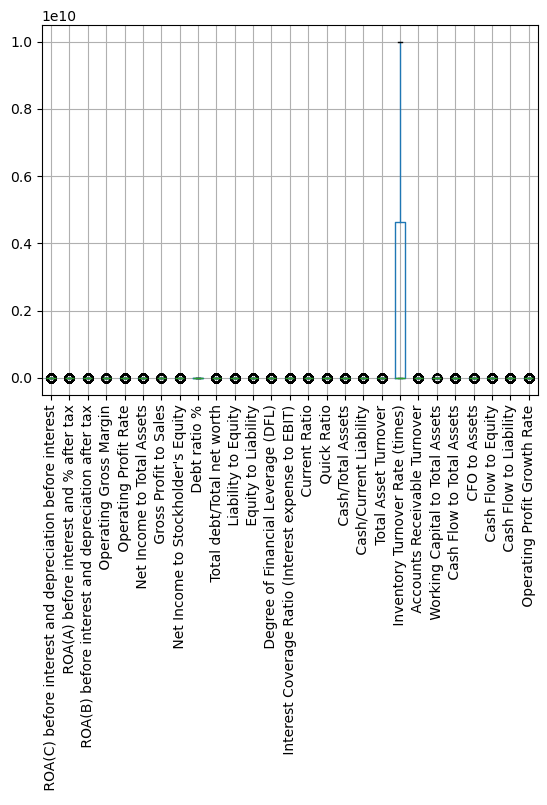

In [12]:
new_features.boxplot()
plt.xticks(rotation = 90)
plt.show()

In [13]:
def scale_data(dataset: pd.DataFrame) -> pd.DataFrame:
    numeric_columns = dataset.select_dtypes(include=["int", "float"]).columns
    scaler = StandardScaler()
    dataset[numeric_columns] = scaler.fit_transform(dataset[numeric_columns])
    return dataset


In [14]:
new_features = scale_data(new_features)

# 

### checking the correlation of the features 

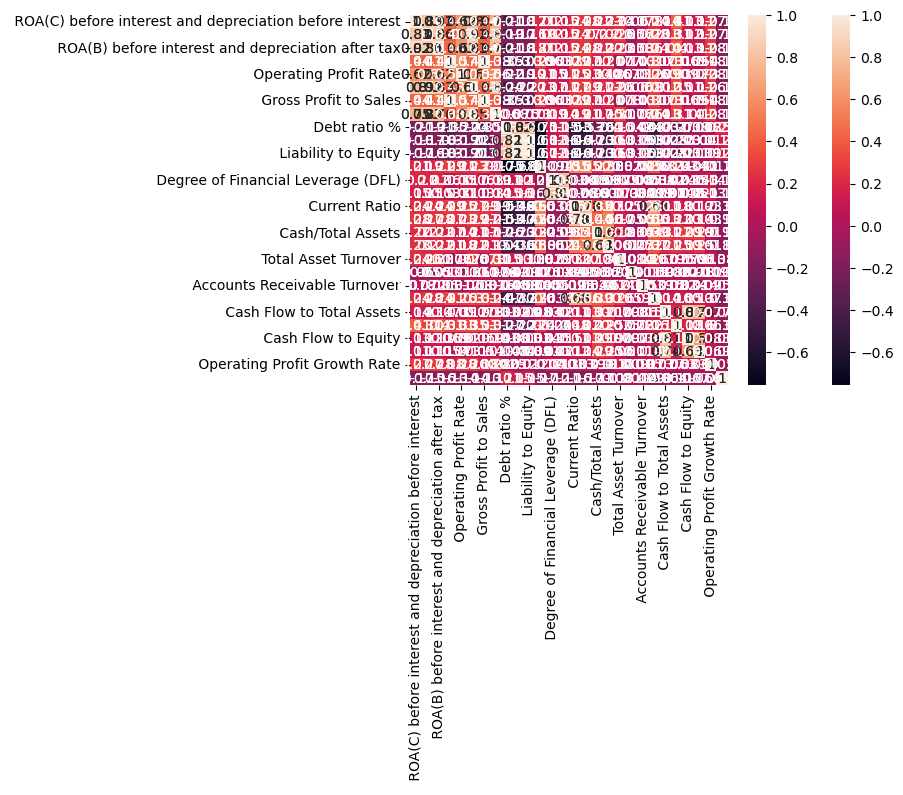

In [63]:
pd.set_option("display.max_columns",None)
sns.heatmap(new_features.corr(), annot = True)
plt.show()

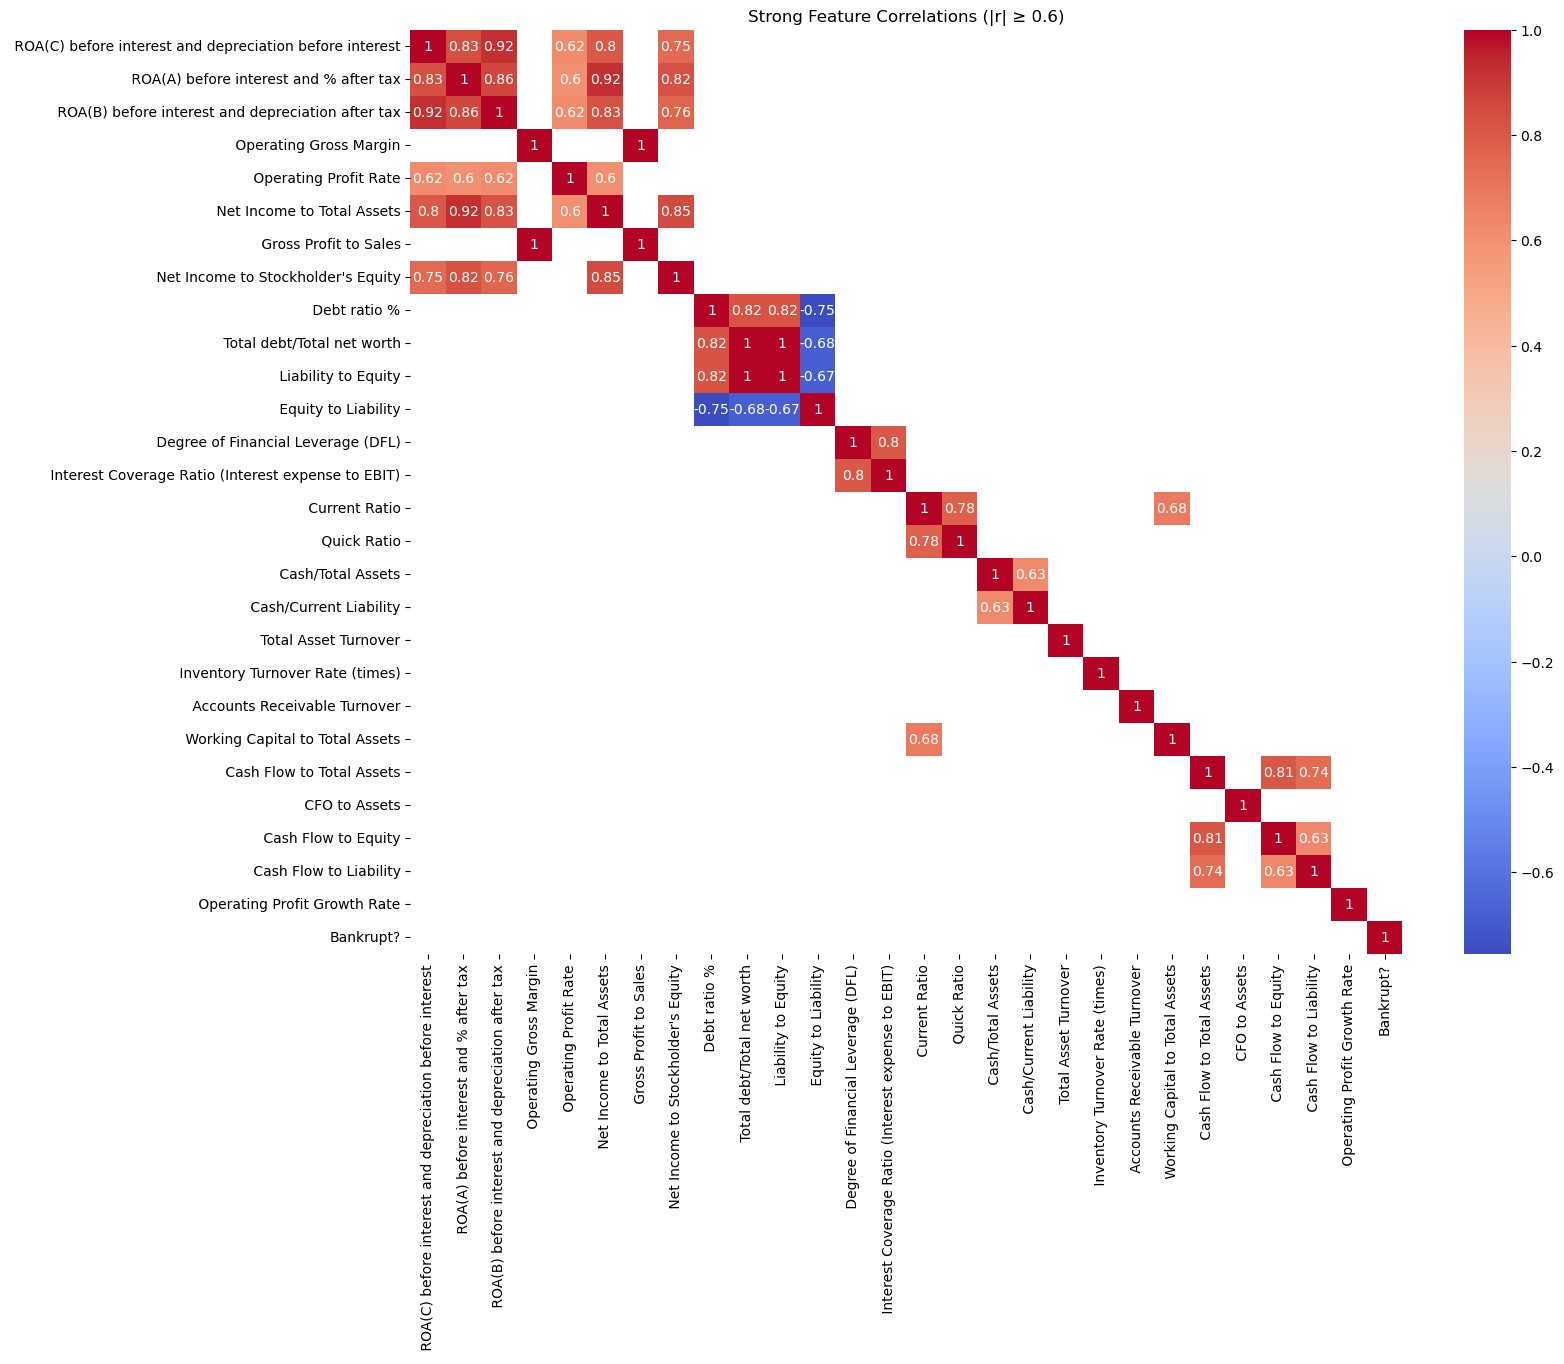

In [64]:
corr = new_features.corr()
plt.figure(figsize=(16,12))
sns.heatmap(corr[(corr >= 0.6) | (corr <= -0.6)], cmap='coolwarm', annot=True)
plt.title("Strong Feature Correlations (|r| ≥ 0.6)")
plt.show()


#

### spliting the Data into Traing and testing data 

In [16]:
from sklearn.model_selection  import train_test_split 

In [17]:
X =  new_features

In [18]:
y = features["Bankrupt?"]

In [19]:
x_train,x_test,y_train,y_test = train_test_split(X,y,random_state = 42 , test_size = 0.20)

# 

## Training the Classification models

# Logistic Regression

In [20]:
LR = LogisticRegression()

In [21]:
y_train.value_counts()

Bankrupt?
0    5286
1     169
Name: count, dtype: int64

In [22]:
y_test.value_counts()

Bankrupt?
0    1313
1      51
Name: count, dtype: int64

#### 

### For solving the bias we used the SMOTE function to balance the data 

In [23]:
from imblearn.over_sampling import SMOTE

In [24]:
sm = SMOTE(random_state = 42)

In [25]:
x_res,y_res = sm.fit_resample(X,y)

In [26]:
y_res.value_counts()

Bankrupt?
1    6599
0    6599
Name: count, dtype: int64

In [27]:
LR.fit(x_res,y_res)

LogisticRegression()

In [28]:
y_pred = LR.predict(x_test)

In [29]:
confusion_matrix(y_test,y_pred)

array([[1077,  236],
       [   3,   48]], dtype=int64)

In [30]:
accuracy_score(y_test,y_pred)

0.8247800586510264

In [31]:
y_test.value_counts()

Bankrupt?
0    1313
1      51
Name: count, dtype: int64

In [32]:
pd.Series(y_pred).value_counts()

0    1080
1     284
Name: count, dtype: int64

In [33]:
f1_score(y_test,y_pred)

0.2865671641791045

In [34]:
recall_score(y_test,y_pred)

0.9411764705882353

# 

# KNN Classifier

In [35]:
KNN = KNeighborsClassifier(n_neighbors=2, n_jobs = -1)

In [36]:
KNN.fit(x_res,y_res)

KNeighborsClassifier(n_jobs=-1, n_neighbors=2)

In [37]:
y_prediction = KNN.predict(x_test)

In [38]:
pd.Series(y_prediction).value_counts()

0    1313
1      51
Name: count, dtype: int64

In [39]:
confusion_matrix(y_test,y_prediction)

array([[1313,    0],
       [   0,   51]], dtype=int64)

In [40]:
accuracy_score(y_test,y_prediction)

1.0

In [41]:
f1_score(y_test,y_prediction)

1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1313
           1       1.00      1.00      1.00        51

    accuracy                           1.00      1364
   macro avg       1.00      1.00      1.00      1364
weighted avg       1.00      1.00      1.00      1364



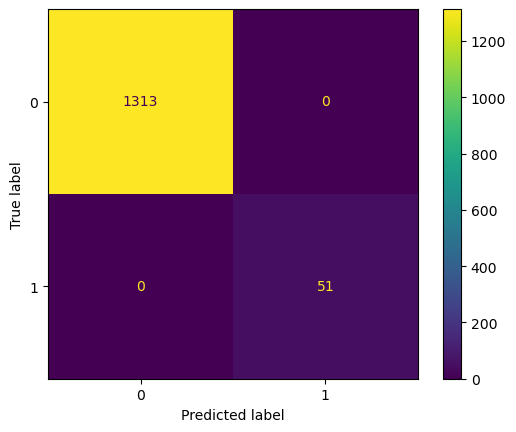

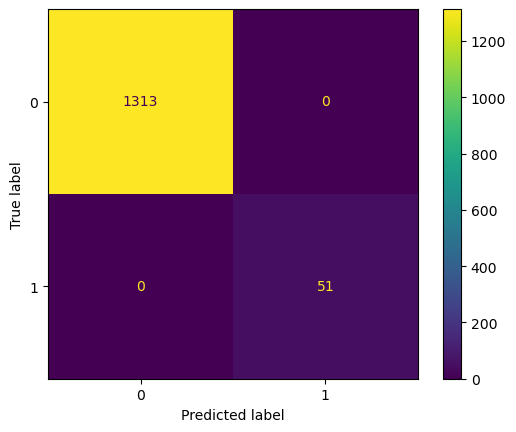

In [68]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = KNN.predict(x_test)

print(classification_report(y_test, y_prediction))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_prediction)).plot()
plt.show()


#### 

#### Now we used the cross validation for testing the model via providing the multiple input and checking the accuracy of the model 

In [42]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(KNN, x_res, y_res, cv=5, scoring='accuracy')
print(scores, scores.mean())


[0.94242424 0.93977273 0.97575758 0.9806745  0.98294809] 0.9643154259533571


In [43]:
from sklearn.metrics import accuracy_score
train_pred = KNN.predict(x_res)
test_pred = KNN.predict(x_test)

print("Train Accuracy:", accuracy_score(y_res, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))


Train Accuracy: 0.9999242309440824
Test Accuracy: 1.0


# 

# Decision Tree Classifier

In [44]:
from sklearn.tree import DecisionTreeClassifier

In [45]:
DTC = DecisionTreeClassifier(criterion='entropy',max_depth = 17, class_weight = 'balanced' , random_state = 42)

In [46]:
DTC.fit(x_res,y_res)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=17, random_state=42)

In [47]:
y_pred_DTC = DTC.predict(x_test)

In [48]:
pd.Series(y_pred_DTC).value_counts()

0    1298
1      66
Name: count, dtype: int64

In [49]:
accuracy_score(y_test,y_pred_DTC)

0.9890029325513197

In [50]:
confusion_matrix(y_test,y_pred_DTC)

array([[1298,   15],
       [   0,   51]], dtype=int64)

In [51]:
print(classification_report(y_test,y_pred_DTC))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1313
           1       0.77      1.00      0.87        51

    accuracy                           0.99      1364
   macro avg       0.89      0.99      0.93      1364
weighted avg       0.99      0.99      0.99      1364



In [52]:
f1_score(y_test,y_pred_DTC)

0.8717948717948718

# 

# Random Forest Classifier

In [53]:
RFC = RandomForestClassifier(n_estimators = 10, criterion='entropy',max_depth = 17, class_weight = 'balanced' , random_state = 42)

In [54]:
RFC.fit(x_res,y_res)

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=17, n_estimators=10, random_state=42)

In [55]:
y_pred_RFC = RFC.predict(x_test)

In [56]:
print(classification_report(y_test,y_pred_RFC))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1313
           1       0.76      1.00      0.86        51

    accuracy                           0.99      1364
   macro avg       0.88      0.99      0.93      1364
weighted avg       0.99      0.99      0.99      1364



In [57]:
accuracy_score(y_test,y_pred_RFC)

0.9882697947214076

In [58]:
f1_score(y_test,y_pred_RFC)

0.864406779661017

# 

## Conclusion:
- After testing all the models I choosed the KNN model because it was more accurate than other algorithm
- For KNN accuracy score was 1 and f1 score was also close to 1 because of these conditions we choose this model 

# 